In [1]:
import os
import sys

print("python executable:", sys.executable)
print("cwd:", os.getcwd())

from dust3r.model import AsymmetricCroCo3DStereo
print("dust3r import ok")

python executable: d:\anaconda\envs\dust3r\python.exe
cwd: d:\Road to st louis\Hustle\CV559\cse559-BEV-Project\notebooks
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


d:\anaconda\envs\dust3r\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dust3r import ok


In [2]:
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


C:\Users\LENOVO\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [3]:
img_dir = Path("../data/selected_frame/frame_000030")
out_dir = Path("./dust3r_output/frame_000030")
out_dir.mkdir(parents=True, exist_ok=True)

img_paths = [
    img_dir / "front_left.png",
    img_dir / "front.png",
    img_dir / "front_right.png",
]

print("img_dir:", img_dir.resolve())
print("out_dir:", out_dir.resolve())

for p in img_paths:
    print(p, p.exists())

img_dir: D:\Road to st louis\Hustle\CV559\cse559-BEV-Project\data\selected_frame\frame_000030
out_dir: D:\Road to st louis\Hustle\CV559\cse559-BEV-Project\notebooks\dust3r_output\frame_000030
..\data\selected_frame\frame_000030\front_left.png True
..\data\selected_frame\frame_000030\front.png True
..\data\selected_frame\frame_000030\front_right.png True


In [ ]:
#loading model
model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"

model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)
model.eval()

print("model loaded")

model loaded


In [ ]:
#inference
images = load_images([str(p) for p in img_paths], size=512)

pairs = make_pairs(
    images,
    scene_graph="complete",
    prefilter=None,
    symmetrize=True
)

output = inference(
    pairs,
    model,
    device,
    batch_size=1
)

print("inference done")
print(output.keys())

>> Loading a list of 3 images
 - adding ..\data\selected_frame\frame_000030\front_left.png with resolution 1920x1280 --> 512x336
 - adding ..\data\selected_frame\frame_000030\front.png with resolution 1920x1280 --> 512x336
 - adding ..\data\selected_frame\frame_000030\front_right.png with resolution 1920x1280 --> 512x336
 (Found 3 images)
>> Inference with model on 6 image pairs


  0%|          | 0/6 [00:00<?, ?it/s]C:\Users\LENOVO\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
C:\Users\LENOVO\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
C:\Users\LENOVO\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 6/6 [00:04<00:00,  1.24it/s]

inference done
dict_keys(['view1', 'view2', 'pred1', 'pred2', 'loss'])


In [6]:
#global alignment
scene = global_aligner(
    output,
    device=device,
    mode=GlobalAlignerMode.PointCloudOptimizer
)

loss = scene.compute_global_alignment(
    init="mst",
    niter=400,
    schedule="cosine",
    lr=0.01
)

print("global alignment done")
print("final loss:", loss)

 init edge (2*,1*) score=np.float64(13.257074356079102)
 init edge (0*,1) score=np.float64(9.8793363571167)
 init loss = 0.006748981773853302
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 400/400 [00:16<00:00, 24.08it/s, lr=1.1542e-06 loss=0.00437562] 

global alignment done
final loss: 0.004375615157186985


In [30]:
# info
imgs = scene.imgs
focals = scene.get_focals()
poses = scene.get_im_poses()
pts3d = scene.get_pts3d()

# use RAW confidence maps (not transformed get_conf())
conf_maps = scene.im_conf

print("num images:", len(imgs))
print("num pts3d maps:", len(pts3d))
print("num raw conf maps:", len(conf_maps))

imgs_np = [np.array(im) for im in imgs]
pts3d_np = [p.detach().cpu().numpy() for p in pts3d]
conf_np = [c.detach().cpu().numpy() for c in conf_maps]
focals_np = [f.detach().cpu().numpy() if torch.is_tensor(f) else np.array(f) for f in focals]
poses_np = [p.detach().cpu().numpy() if torch.is_tensor(p) else np.array(p) for p in poses]

print("converted to cpu numpy")
for i in range(len(imgs_np)):
    print(f"img[{i}] shape:", imgs_np[i].shape)
    print(f"pts3d[{i}] shape:", pts3d_np[i].shape)
    print(f"raw_conf[{i}] shape:", conf_np[i].shape)
    print(
        f"raw_conf[{i}] stats: "
        f"min={conf_np[i].min():.4f}, "
        f"max={conf_np[i].max():.4f}, "
        f"mean={conf_np[i].mean():.4f}"
    )
    print(f"focal[{i}] shape:", focals_np[i].shape)
    print(f"pose[{i}] shape:", poses_np[i].shape)
    print("-" * 40)

num images: 3
num pts3d maps: 3
num raw conf maps: 3
converted to cpu numpy
img[0] shape: (336, 512, 3)
pts3d[0] shape: (336, 512, 3)
raw_conf[0] shape: (336, 512)
raw_conf[0] stats: min=1.0001, max=9.8324, mean=4.1946
focal[0] shape: (1,)
pose[0] shape: (4, 4)
----------------------------------------
img[1] shape: (336, 512, 3)
pts3d[1] shape: (336, 512, 3)
raw_conf[1] shape: (336, 512)
raw_conf[1] stats: min=1.0000, max=11.4906, mean=3.0493
focal[1] shape: (1,)
pose[1] shape: (4, 4)
----------------------------------------
img[2] shape: (336, 512, 3)
pts3d[2] shape: (336, 512, 3)
raw_conf[2] shape: (336, 512)
raw_conf[2] stats: min=1.0000, max=14.6632, mean=5.1187
focal[2] shape: (1,)
pose[2] shape: (4, 4)
----------------------------------------


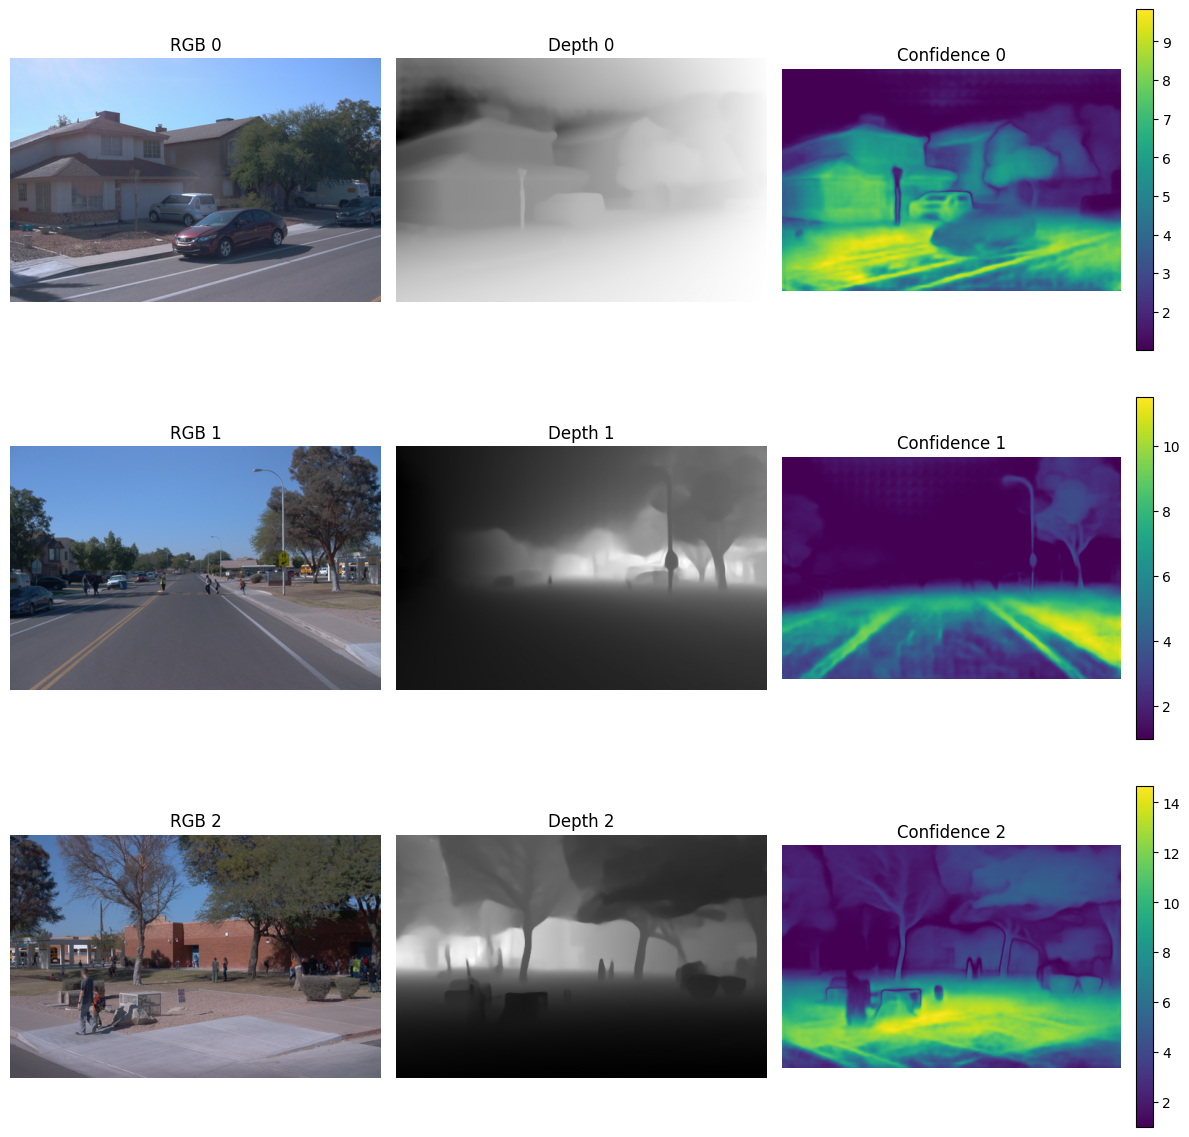

saved: dust3r_output\frame_000030\rgb_depth_confidence_overview.png


In [31]:
n = len(imgs_np)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(n):
    # RGB
    axes[i, 0].imshow(imgs_np[i])
    axes[i, 0].set_title(f"RGB {i}")
    axes[i, 0].axis("off")

    depth_map = pts3d_np[i][..., 2]
    axes[i, 1].imshow(depth_map, cmap="gray")
    axes[i, 1].set_title(f"Depth {i}")
    axes[i, 1].axis("off")

    # Continuous confidence
    conf_map = conf_np[i]
    im = axes[i, 2].imshow(conf_map, cmap="viridis")
    axes[i, 2].set_title(f"Confidence {i}")
    axes[i, 2].axis("off")
    fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()

overview_path = out_dir / "rgb_depth_confidence_overview.png"
plt.savefig(overview_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", overview_path)

In [32]:
np.save(out_dir / "imgs.npy", np.array(imgs_np, dtype=object))
np.save(out_dir / "pts3d.npy", np.array(pts3d_np, dtype=object))
np.save(out_dir / "raw_conf_maps.npy", np.array(conf_np, dtype=object))
np.save(out_dir / "focals.npy", np.array(focals_np, dtype=object))
np.save(out_dir / "poses.npy", np.array(poses_np, dtype=object))

print("saved imgs / pts3d / raw_conf_maps / focals / poses")
print("to:", out_dir)

saved imgs / pts3d / raw_conf_maps / focals / poses
to: dust3r_output\frame_000030


In [33]:
for i in range(len(conf_np)):
    conf = conf_np[i]
    print(f"image {i}")
    print(f"  min  : {conf.min():.4f}")
    print(f"  max  : {conf.max():.4f}")
    print(f"  mean : {conf.mean():.4f}")
    print(f"  q50  : {np.quantile(conf, 0.50):.4f}")
    print(f"  q70  : {np.quantile(conf, 0.70):.4f}")
    print(f"  q80  : {np.quantile(conf, 0.80):.4f}")
    print(f"  q90  : {np.quantile(conf, 0.90):.4f}")
    print("-" * 40)

image 0
  min  : 1.0001
  max  : 9.8324
  mean : 4.1946
  q50  : 4.1000
  q70  : 5.8311
  q80  : 7.0008
  q90  : 7.8800
----------------------------------------
image 1
  min  : 1.0000
  max  : 11.4906
  mean : 3.0493
  q50  : 1.8618
  q70  : 3.4336
  q80  : 5.1545
  q90  : 7.3108
----------------------------------------
image 2
  min  : 1.0000
  max  : 14.6632
  mean : 5.1187
  q50  : 3.5554
  q70  : 6.3965
  q80  : 9.6084
  q90  : 11.7850
----------------------------------------
